In [ ]:
# ─────────────────────────────────────────────────
# Import all required libraries
# STA281 CEP — Statistical Investigation of Online Shopping Behavior
# ─────────────────────────────────────────────────

# Standard numeric and data manipulation libraries
import pandas as pd                          # For reading CSV and DataFrame operations
import numpy as np                           # For numerical computations and arrays

# Visualization libraries
import matplotlib.pyplot as plt              # Core plotting library
import seaborn as sns                        # High-level statistical plots

# Statistical analysis libraries
from scipy import stats                      # Hypothesis tests, distributions, CLT
import statsmodels.api as sm                 # OLS regression with full diagnostics

# Suppress unnecessary warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot styling
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

print("All libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version:  {np.__version__}")


All libraries imported successfully.
Pandas version: 2.2.2
NumPy version:  2.0.2


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


In [ ]:
df = pd.read_csv('online_shoppers_intention.csv')

In [ ]:
# Display basic structural information
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Number of rows (sessions)  : {df.shape[0]:,}")
print(f"Number of columns (features): {df.shape[1]}")
print()

DATASET OVERVIEW
Number of rows (sessions)  : 12,330
Number of columns (features): 18



In [ ]:
# Show all column names and their data types
print("Column Names and Data Types:")
print("-" * 40)
print(df.dtypes.to_string())
print()

Column Names and Data Types:
----------------------------------------
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool



In [ ]:
# Show first 10 rows to confirm data loaded correctly
print("First 10 Rows:")
print(df.head(10).to_string())
print()

First 10 Rows:
   Administrative  Administrative_Duration  Informational  Informational_Duration  ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  Browser  Region  TrafficType        VisitorType  Weekend  Revenue
0               0                      0.0              0                     0.0               1                 0.000000     0.200000   0.200000         0.0         0.0   Feb                 1        1       1            1  Returning_Visitor    False    False
1               0                      0.0              0                     0.0               2                64.000000     0.000000   0.100000         0.0         0.0   Feb                 2        2       1            2  Returning_Visitor    False    False
2               0                      0.0              0                     0.0               1                 0.000000     0.200000   0.200000         0.0         0.0   Feb                 4     

In [ ]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum().to_string())

Missing Values per Column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0


In [ ]:
# Duplicate row detection
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 125


In [ ]:
#Dropping duplicate rows
df = df.drop_duplicates()

print(f"Rows after removing duplicates: {len(df)}")

Rows after removing duplicates: 12205


In [ ]:
# Check Revenue class distribution
distribution = pd.DataFrame({
    'Count': df['Revenue'].value_counts(),
    'Percentage': (df['Revenue'].value_counts(normalize=True) * 100).round(2)
})

print(distribution)

         Count  Percentage
Revenue                   
False    10297       84.37
True      1908       15.63


In [ ]:
# Convert boolean columns to integers (0/1) for correlation and regression
# This is necessary because statistical functions need numeric input
df['Revenue_int'] = df['Revenue'].astype(int)       # 0 = No Purchase, 1 = Purchase



In [ ]:
# Define the four focal variables for this project
focus_vars = ['BounceRates', 'ExitRates', 'PageValues', 'ProductRelated']


In [ ]:
# Descriptive summary of VisitorType categories
print("VisitorType breakdown:")
vc = df['VisitorType'].value_counts()
for vtype, count in vc.items():
    pct = count / len(df) * 100
    print(f"  {vtype:<25} n={count:>6,}  ({pct:.2f}%)")


VisitorType breakdown:
  Returning_Visitor         n=10,431  (85.46%)
  New_Visitor               n= 1,693  (13.87%)
  Other                     n=    81  (0.66%)


In [ ]:
#Preprocessing complete. Dataset ready for analysis.
#  Descriptive Statistics started

In [ ]:
 # Basic statistics using .describe() — covers count, mean, std, min, quartiles, max
desc = df[focus_vars].describe().round(4)
print(desc.to_string())
print()


       BounceRates   ExitRates  PageValues  ProductRelated
count   12205.0000  12205.0000  12205.0000      12205.0000
mean        0.0204      0.0415      5.9496         32.0456
std         0.0453      0.0462     18.6537         44.5936
min         0.0000      0.0000      0.0000          0.0000
25%         0.0000      0.0142      0.0000          8.0000
50%         0.0029      0.0250      0.0000         18.0000
75%         0.0167      0.0485      0.0000         38.0000
max         0.2000      0.2000    361.7637        705.0000



In [ ]:

# Additional shape statistics not in .describe()
print("IQR (Interquartile Range = Q3 - Q1):")
iqr = df[focus_vars].quantile(0.75) - df[focus_vars].quantile(0.25)
print(iqr.round(4).to_string())
print()

print("Skewness (measures asymmetry of distribution):")
print(df[focus_vars].skew().round(4).to_string())
print()

print("Kurtosis (measures tail heaviness relative to Normal):")
print(df[focus_vars].kurtosis().round(4).to_string())


IQR (Interquartile Range = Q3 - Q1):
BounceRates        0.0167
ExitRates          0.0343
PageValues         0.0000
ProductRelated    30.0000

Skewness (measures asymmetry of distribution):
BounceRates       3.1624
ExitRates         2.2346
PageValues        6.3510
ProductRelated    4.3334

Kurtosis (measures tail heaviness relative to Normal):
BounceRates        9.3340
ExitRates          4.6421
PageValues        64.9980
ProductRelated    31.0727


In [ ]:
#Histogram plots for all four variables

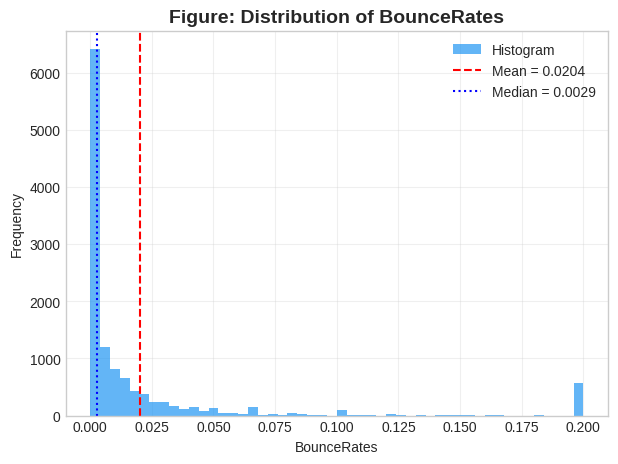

In [ ]:
var = 'BounceRates'

plt.figure(figsize=(7, 5))

# Histogram WITH label
plt.hist(df[var], bins=50, color='#2196F3', alpha=0.7, label='Histogram')

# Mean line
plt.axvline(df[var].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean = {df[var].mean():.4f}")

# Median line
plt.axvline(df[var].median(), color='blue', linestyle=':',
            linewidth=1.5, label=f"Median = {df[var].median():.4f}")

plt.title(f'Figure: Distribution of {var}', fontsize=14, fontweight='bold')
plt.xlabel(var)
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

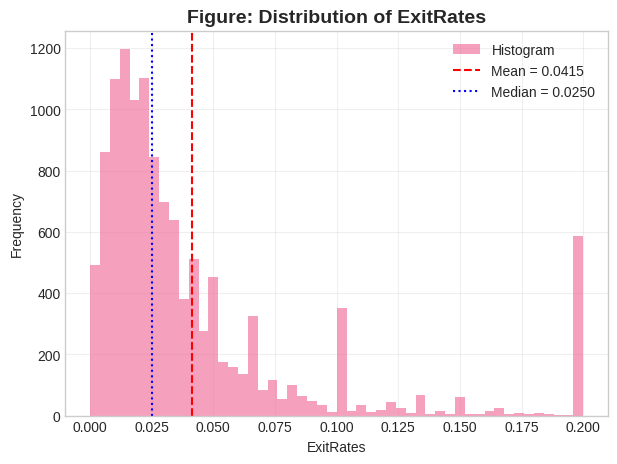

In [ ]:
var = 'ExitRates'

plt.figure(figsize=(7, 5))

# Histogram WITH label
plt.hist(df[var], bins=50, color='#F178A1', alpha=0.7, label='Histogram')

# Mean line
plt.axvline(df[var].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean = {df[var].mean():.4f}")

# Median line
plt.axvline(df[var].median(), color='blue', linestyle=':',
            linewidth=1.5, label=f"Median = {df[var].median():.4f}")

plt.title(f'Figure: Distribution of {var}', fontsize=14, fontweight='bold')
plt.xlabel(var)
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

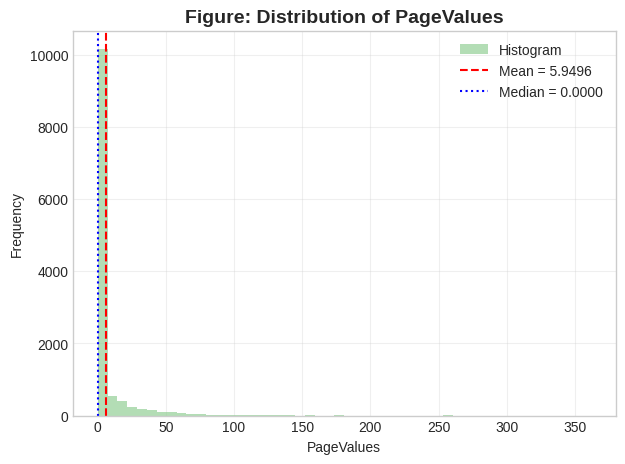

In [ ]:
var = 'PageValues'

plt.figure(figsize=(7, 5))

# Histogram WITH label
plt.hist(df[var], bins=50, color='#93CF96', alpha=0.7, label='Histogram')

# Mean line
plt.axvline(df[var].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean = {df[var].mean():.4f}")

# Median line
plt.axvline(df[var].median(), color='blue', linestyle=':',
            linewidth=1.5, label=f"Median = {df[var].median():.4f}")

plt.title(f'Figure: Distribution of {var}', fontsize=14, fontweight='bold')
plt.xlabel(var)
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

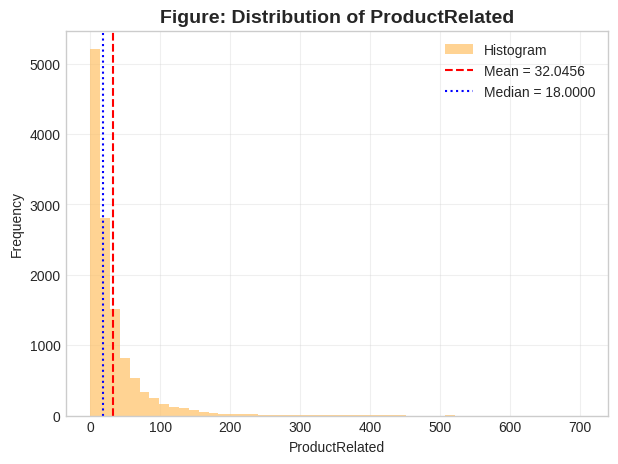

In [ ]:
var = 'ProductRelated'

plt.figure(figsize=(7, 5))

# Histogram WITH label
plt.hist(df[var], bins=50, color='#FFC166', alpha=0.7, label='Histogram')

# Mean line
plt.axvline(df[var].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f"Mean = {df[var].mean():.4f}")

# Median line
plt.axvline(df[var].median(), color='blue', linestyle=':',
            linewidth=1.5, label=f"Median = {df[var].median():.4f}")

plt.title(f'Figure: Distribution of {var}', fontsize=14, fontweight='bold')
plt.xlabel(var)
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#Boxplots — comparing purchasers vs non-purchasers


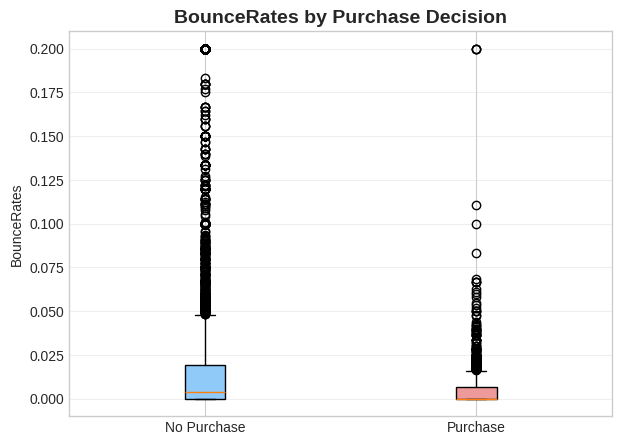

In [ ]:
var = 'BounceRates'

group_no  = df[df['Revenue'] == False][var].dropna()
group_yes = df[df['Revenue'] == True][var].dropna()

plt.figure(figsize=(7, 5))

bp = plt.boxplot([group_no, group_yes],
                 patch_artist=True,
                 labels=['No Purchase', 'Purchase'])

bp['boxes'][0].set_facecolor('#90CAF9')   # No Purchase
bp['boxes'][1].set_facecolor('#EF9A9A')   # Purchase

plt.title(f'{var} by Purchase Decision', fontsize=14, fontweight='bold')
plt.ylabel(var)
plt.grid(alpha=0.3, axis='y')

plt.show()

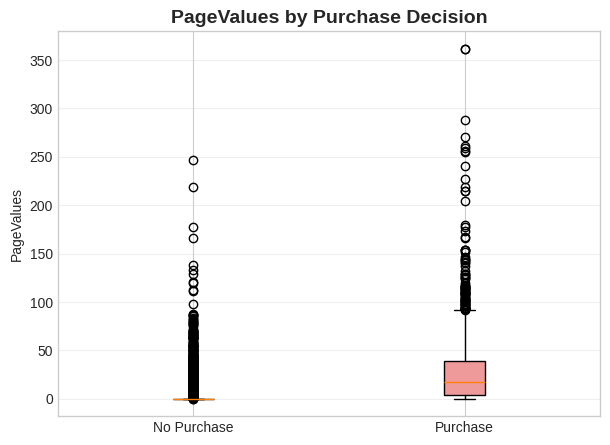

In [ ]:
var = 'PageValues'

group_no  = df[df['Revenue'] == False][var].dropna()
group_yes = df[df['Revenue'] == True][var].dropna()

plt.figure(figsize=(7, 5))

bp = plt.boxplot([group_no, group_yes],
                 patch_artist=True,
                 labels=['No Purchase', 'Purchase'])

bp['boxes'][0].set_facecolor('#90CAF9')   # No Purchase
bp['boxes'][1].set_facecolor('#EF9A9A')   # Purchase

plt.title(f'{var} by Purchase Decision', fontsize=14, fontweight='bold')
plt.ylabel(var)
plt.grid(alpha=0.3, axis='y')

plt.show()

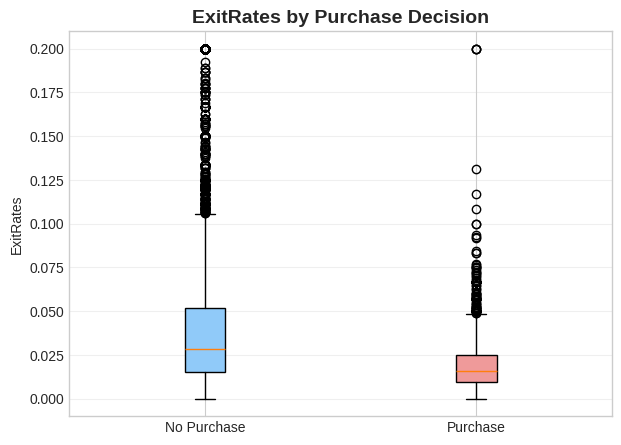

In [ ]:
var = 'ExitRates'

group_no  = df[df['Revenue'] == False][var].dropna()
group_yes = df[df['Revenue'] == True][var].dropna()

plt.figure(figsize=(7, 5))

bp = plt.boxplot([group_no, group_yes],
                 patch_artist=True,
                 labels=['No Purchase', 'Purchase'])

bp['boxes'][0].set_facecolor('#90CAF9')   # No Purchase
bp['boxes'][1].set_facecolor('#EF9A9A')   # Purchase

plt.title(f'{var} by Purchase Decision', fontsize=14, fontweight='bold')
plt.ylabel(var)
plt.grid(alpha=0.3, axis='y')

plt.show()

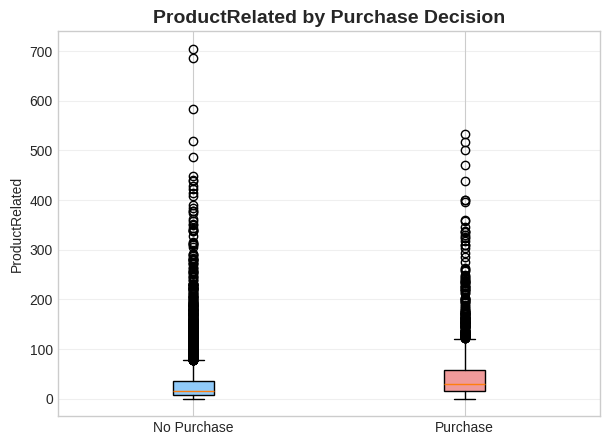

In [ ]:
var = 'ProductRelated'

group_no  = df[df['Revenue'] == False][var].dropna()
group_yes = df[df['Revenue'] == True][var].dropna()

plt.figure(figsize=(7, 5))

bp = plt.boxplot([group_no, group_yes],
                 patch_artist=True,
                 labels=['No Purchase', 'Purchase'])

bp['boxes'][0].set_facecolor('#90CAF9')   # No Purchase
bp['boxes'][1].set_facecolor('#EF9A9A')   # Purchase

plt.title(f'{var} by Purchase Decision', fontsize=14, fontweight='bold')
plt.ylabel(var)
plt.grid(alpha=0.3, axis='y')

plt.show()

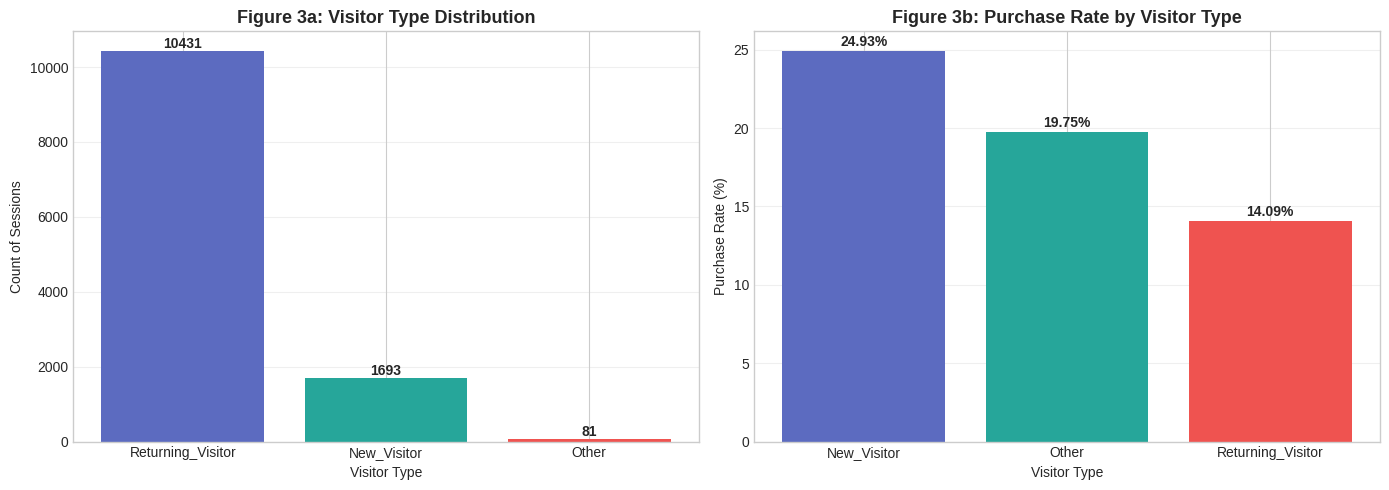

Visitor Type Analysis:
  Returning_Visitor: n=10,431, purchase_rate=14.09%
  New_Visitor: n=1,693, purchase_rate=24.93%
  Other: n=81, purchase_rate=19.75%


In [ ]:
# Visitor Type — distribution and purchase rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: Count of each visitor type
vc = df['VisitorType'].value_counts()
axes[0].bar(vc.index, vc.values, color=['#5C6BC0', '#26A69A', '#EF5350'])
axes[0].set_title('Figure 3a: Visitor Type Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Visitor Type')
axes[0].set_ylabel('Count of Sessions')
axes[0].grid(alpha=0.3, axis='y')
for bar, val in zip(axes[0].patches, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 str(val), ha='center', fontsize=10, fontweight='bold')

# Right chart: Purchase rate (%) per visitor type
rev_by_visitor = df.groupby('VisitorType')['Revenue'].mean() * 100
axes[1].bar(rev_by_visitor.index, rev_by_visitor.values,
            color=['#5C6BC0', '#26A69A', '#EF5350'])
axes[1].set_title('Figure 3b: Purchase Rate by Visitor Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Visitor Type')
axes[1].set_ylabel('Purchase Rate (%)')
axes[1].grid(alpha=0.3, axis='y')
for bar, val in zip(axes[1].patches, rev_by_visitor.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print exact values
print("Visitor Type Analysis:")
for vtype in df['VisitorType'].unique():
    sub = df[df['VisitorType'] == vtype]
    print(f"  {vtype}: n={len(sub):,}, purchase_rate={sub['Revenue'].mean()*100:.2f}%")


In [ ]:
#Probability Analysis & Bayes' Theorem

In [ ]:
n = len(df)
n_purchase = df['Revenue'].sum()

# ── Basic Probabilities ──
P_purchase = n_purchase / n
P_no_purchase = 1 - P_purchase

print(f"P(Purchase)    = {n_purchase}/{n} = {P_purchase:.6f} ({P_purchase*100:.2f}%)")
print(f"P(No Purchase) = {P_no_purchase:.6f} ({P_no_purchase*100:.2f}%)")
print()

n = len(df)

print("=== Probability of Visitor Types ===")

for vtype in ['New_Visitor', 'Returning_Visitor', 'Other']:

    count = len(df[df['VisitorType'] == vtype])
    p_vtype = count / n

    print(f"{vtype}")
    print(f"  Count = {count}")
    print(f"  P({vtype}) = {count}/{n} = {p_vtype:.6f} ({p_vtype*100:.2f}%)")
    print()

# ── Conditional Probabilities ──
print("=== Conditional Probabilities P(Revenue=True | VisitorType) ===")

for vtype in ['New_Visitor', 'Returning_Visitor', 'Other']:
    sub = df[df['VisitorType'] == vtype]

    total_sessions = len(sub)
    purchases = sub['Revenue'].sum()
    p_cond = purchases / total_sessions

    print(f"{vtype}")
    print(f"  Total Sessions = {total_sessions}")
    print(f"  Purchases      = {purchases}")
    print(
        f"  P(Purchase | {vtype}) = "
        f"{purchases}/{total_sessions} = {p_cond:.6f} ({p_cond*100:.2f}%)"
    )
    print()

# ── Bayes' Theorem ──
P_NV = len(df[df['VisitorType'] == 'New_Visitor']) / n
P_Rev_NV = df[df['VisitorType'] == 'New_Visitor']['Revenue'].mean()
P_NV_given_Rev = (P_Rev_NV * P_NV) / P_purchase

print("=== Bayes' Theorem Results ===")
print(
    f"P(New_Visitor | Revenue=True) = "
    f"{P_NV_given_Rev:.6f} ({P_NV_given_Rev*100:.2f}%)"
)

P_RV = len(df[df['VisitorType'] == 'Returning_Visitor']) / n
P_Rev_RV = df[df['VisitorType'] == 'Returning_Visitor']['Revenue'].mean()
P_RV_given_Rev = (P_Rev_RV * P_RV) / P_purchase

print(
    f"P(Returning_Visitor | Revenue=True) = "
    f"{P_RV_given_Rev:.6f} ({P_RV_given_Rev*100:.2f}%)"
)

P(Purchase)    = 1908/12205 = 0.156329 (15.63%)
P(No Purchase) = 0.843671 (84.37%)

=== Probability of Visitor Types ===
New_Visitor
  Count = 1693
  P(New_Visitor) = 1693/12205 = 0.138714 (13.87%)

Returning_Visitor
  Count = 10431
  P(Returning_Visitor) = 10431/12205 = 0.854650 (85.46%)

Other
  Count = 81
  P(Other) = 81/12205 = 0.006637 (0.66%)

=== Conditional Probabilities P(Revenue=True | VisitorType) ===
New_Visitor
  Total Sessions = 1693
  Purchases      = 422
  P(Purchase | New_Visitor) = 422/1693 = 0.249262 (24.93%)

Returning_Visitor
  Total Sessions = 10431
  Purchases      = 1470
  P(Purchase | Returning_Visitor) = 1470/10431 = 0.140926 (14.09%)

Other
  Total Sessions = 81
  Purchases      = 16
  P(Purchase | Other) = 16/81 = 0.197531 (19.75%)

=== Bayes' Theorem Results ===
P(New_Visitor | Revenue=True) = 0.221174 (22.12%)
P(Returning_Visitor | Revenue=True) = 0.770440 (77.04%)


In [ ]:
#Binomial Distribution & CLT Analysis
from scipy.stats import binom

p = df['Revenue'].mean()          # Probability of purchase = 0.1547
n_binom = 20                      # Number of sessions

# ── Binomial Distribution ──
print(f"Binomial Distribution: X ~ B(n={n_binom}, p={p:.4f})")
print(f"E[X] = n*p = {n_binom*p:.4f}")
print(f"Var[X] = n*p*(1-p) = {n_binom*p*(1-p):.4f}")
print(f"Std[X] = {(n_binom*p*(1-p))**0.5:.4f}")
print()
for k in [0, 1, 2, 3, 4, 5]:
    pmf = binom.pmf(k, n_binom, p)
    print(f"  P(X={k:2d}) = C({n_binom},{k}) × {p:.4f}^{k} × {1-p:.4f}^{n_binom-k} = {pmf:.6f}")

# ── CLT Analysis ──
sample_size  = 50
n_simulations = 5000
np.random.seed(42)                # For reproducibility

sample_means = []
for _ in range(n_simulations):
    sample = df['PageValues'].sample(sample_size, replace=True)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print()
print(f"Central Limit Theorem — PageValues (n={sample_size}, simulations={n_simulations})")
print(f"Population mean:          μ = {df['PageValues'].mean():.4f}")
print(f"Population std:           σ = {df['PageValues'].std():.4f}")
print(f"Theoretical SE:       σ/√n = {df['PageValues'].std()/sample_size**0.5:.4f}")
print(f"Empirical mean of x̄:      = {sample_means.mean():.4f}")
print(f"Empirical std of x̄:       = {sample_means.std():.4f}")


Binomial Distribution: X ~ B(n=20, p=0.1563)
E[X] = n*p = 3.1266
Var[X] = n*p*(1-p) = 2.6378
Std[X] = 1.6241

  P(X= 0) = C(20,0) × 0.1563^0 × 0.8437^20 = 0.033378
  P(X= 1) = C(20,1) × 0.1563^1 × 0.8437^19 = 0.123696
  P(X= 2) = C(20,2) × 0.1563^2 × 0.8437^18 = 0.217745
  P(X= 3) = C(20,3) × 0.1563^3 × 0.8437^17 = 0.242084
  P(X= 4) = C(20,4) × 0.1563^4 × 0.8437^16 = 0.190644
  P(X= 5) = C(20,5) × 0.1563^5 × 0.8437^15 = 0.113042

Central Limit Theorem — PageValues (n=50, simulations=5000)
Population mean:          μ = 5.9496
Population std:           σ = 18.6537
Theoretical SE:       σ/√n = 2.6380
Empirical mean of x̄:      = 5.9536
Empirical std of x̄:       = 2.6177


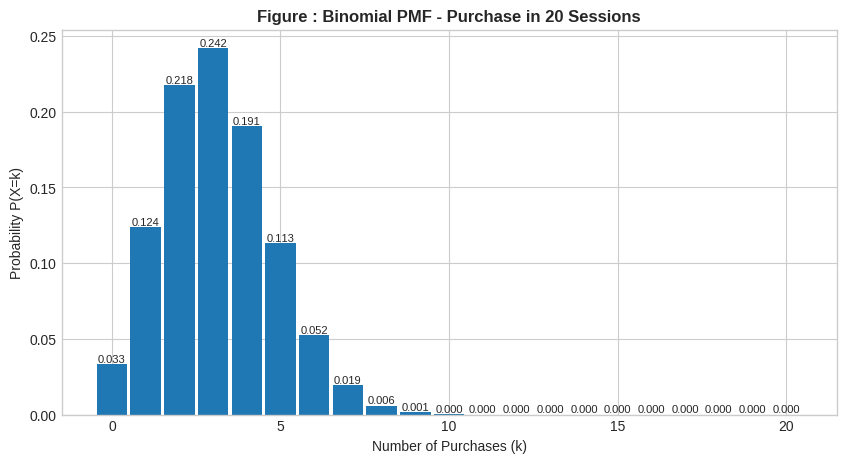

In [ ]:
plt.figure(figsize=(10,5))

k_vals = np.arange(0, 21)
pmf_vals = binom.pmf(k_vals, n_binom, p)

# ── increase bar width ──
bars = plt.bar(k_vals, pmf_vals, width=0.9)

plt.title(
    "Figure : Binomial PMF - Purchase in 20 Sessions",
    fontweight='bold'
)

plt.xlabel("Number of Purchases (k)")
plt.ylabel("Probability P(X=k)")

# ── Add values on top of bars ──
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.show()

In [ ]:
# ================================================================
# Normal Probability Distribution
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ── Compute parameters from dataset ──────────────────────────
mu    = df_clean['PageValues'].mean()
sigma = df_clean['PageValues'].std()

print("=" * 55)
print("  5.5 NORMAL PROBABILITY DISTRIBUTION")
print("=" * 55)

print("\nParameters computed from dataset:")
print("  Mean  (μ) =", round(mu, 4))
print("  Std   (σ) =", round(sigma, 4))

print("""
Normal Distribution Formula:
        1
f(x) = ──── × e^(−(x−μ)²/2σ²)
       σ√2π

Applied to PageValues:
  X ~ N(μ, σ)
""")

print("  X ~ N(", round(mu, 4), ",", round(sigma, 4), ")")

# ── Empirical Rule ────────────────────────────────────────────
print("\n── Empirical Rule (68 − 95 − 99.7 Rule) ──\n")

for z_val, pct in [(1, "≈ 68%"), (2, "≈ 95%"), (3, "≈ 99.7%")]:
    lo = mu - z_val * sigma
    hi = mu + z_val * sigma
    print("  μ ±", z_val, "σ  →  [", round(lo, 4), ",", round(hi, 4), "]  →  ", pct)

# ── Z-score Calculation ───────────────────────────────────────
print("""
── Z-Score (Standard Normal Conversion) ──

Formula:  Z = (x − μ) / σ

The Z-score tells how many standard deviations
a value x is above or below the mean.
""")

# P(PageValues > 20)
x    = 20
z    = (x - mu) / sigma
prob = 1 - norm.cdf(z)

print("  Example: What is P(PageValues > 20)?")
print()
print("  Z = (", x, "−", round(mu, 4), ") /", round(sigma, 4))
print("  Z =", round(z, 4))
print()
print("  P(X > 20) = 1 − Φ(", round(z, 4), ")")
print("            =", round(prob, 4))
print("            =", round(prob * 100, 2), "%")
print()
print("  Interpretation: Under the Normal model,")
print("  approximately", round(prob * 100, 2), "% of sessions")
print("  are expected to have PageValues greater than 20.")

  5.5 NORMAL PROBABILITY DISTRIBUTION

Parameters computed from dataset:
  Mean  (μ) = 5.9496
  Std   (σ) = 18.6537

Normal Distribution Formula:
        1
f(x) = ──── × e^(−(x−μ)²/2σ²)
       σ√2π

Applied to PageValues:
  X ~ N(μ, σ)

  X ~ N( 5.9496 , 18.6537 )

── Empirical Rule (68 − 95 − 99.7 Rule) ──

  μ ± 1 σ  →  [ -12.7041 , 24.6032 ]  →   ≈ 68%
  μ ± 2 σ  →  [ -31.3578 , 43.2569 ]  →   ≈ 95%
  μ ± 3 σ  →  [ -50.0114 , 61.9106 ]  →   ≈ 99.7%

── Z-Score (Standard Normal Conversion) ──

Formula:  Z = (x − μ) / σ

The Z-score tells how many standard deviations
a value x is above or below the mean.

  Example: What is P(PageValues > 20)?

  Z = ( 20 − 5.9496 ) / 18.6537
  Z = 0.7532

  P(X > 20) = 1 − Φ( 0.7532 )
            = 0.2257
            = 22.57 %

  Interpretation: Under the Normal model,
  approximately 22.57 % of sessions
  are expected to have PageValues greater than 20.


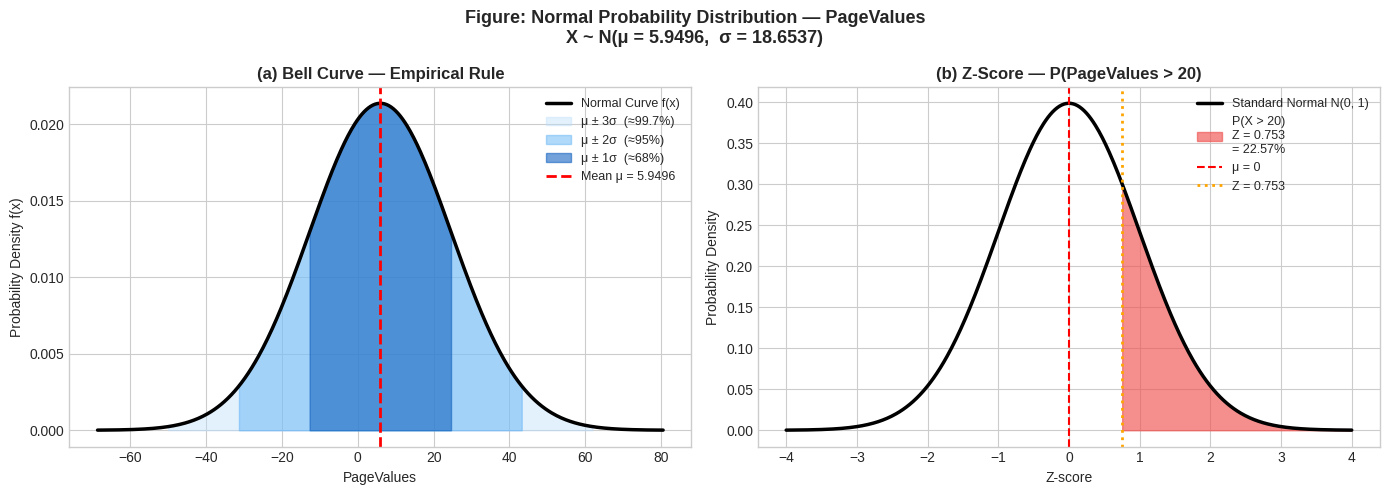

In [ ]:
# ── Figure: Bell Curve with Empirical Rule ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Figure: Normal Probability Distribution — PageValues\n'
    'X ~ N(μ = ' + str(round(mu, 4)) +
    ',  σ = ' + str(round(sigma, 4)) + ')',
    fontsize=13, fontweight='bold'
)

# ── Left: Bell curve with 68-95-99.7 shading ─────────────────
x_vals = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
y_vals = norm.pdf(x_vals, mu, sigma)

axes[0].plot(x_vals, y_vals, 'k-', lw=2.5, label='Normal Curve f(x)')

shading = [
    (3, '#BBDEFB', 0.40, 'μ ± 3σ  (≈99.7%)'),
    (2, '#64B5F6', 0.50, 'μ ± 2σ  (≈95%)'),
    (1, '#1565C0', 0.60, 'μ ± 1σ  (≈68%)'),
]
for z_v, color, alpha, label in shading:
    lo     = mu - z_v * sigma
    hi     = mu + z_v * sigma
    x_fill = np.linspace(lo, hi, 400)
    axes[0].fill_between(
        x_fill,
        norm.pdf(x_fill, mu, sigma),
        color=color, alpha=alpha, label=label
    )

axes[0].axvline(mu, color='red', linestyle='--',
                lw=2, label='Mean μ = ' + str(round(mu, 4)))
axes[0].set_title('(a) Bell Curve — Empirical Rule',
                  fontweight='bold')
axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Probability Density f(x)')
axes[0].legend(fontsize=9)

# ── Right: Standard Normal with Z-score area ──────────────────
x_std = np.linspace(-4, 4, 500)
y_std = norm.pdf(x_std, 0, 1)

axes[1].plot(x_std, y_std, 'k-', lw=2.5,
             label='Standard Normal N(0, 1)')

z_mark  = (20 - mu) / sigma
x_right = np.linspace(z_mark, 4, 300)
axes[1].fill_between(
    x_right,
    norm.pdf(x_right, 0, 1),
    color='#EF5350', alpha=0.65,
    label='P(X > 20)\nZ = ' + str(round(z_mark, 3)) +
          '\n= ' + str(round(prob * 100, 2)) + '%'
)

axes[1].axvline(0, color='red', linestyle='--',
                lw=1.5, label='μ = 0')
axes[1].axvline(z_mark, color='orange', linestyle=':',
                lw=2, label='Z = ' + str(round(z_mark, 3)))
axes[1].set_title('(b) Z-Score — P(PageValues > 20)',
                  fontweight='bold')
axes[1].set_xlabel('Z-score')
axes[1].set_ylabel('Probability Density')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_normal_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

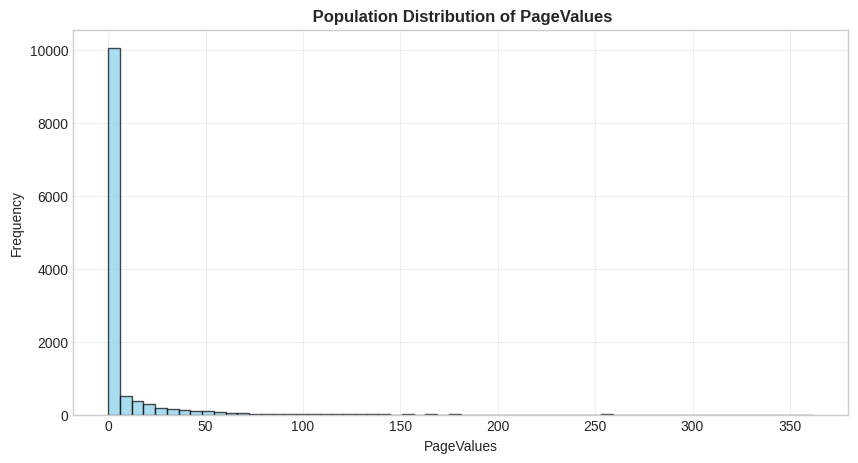

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['PageValues'], bins=60, color='skyblue', alpha=0.7, edgecolor='black')

plt.title(
    " Population Distribution of PageValues",
    fontweight='bold'
)

plt.xlabel("PageValues")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

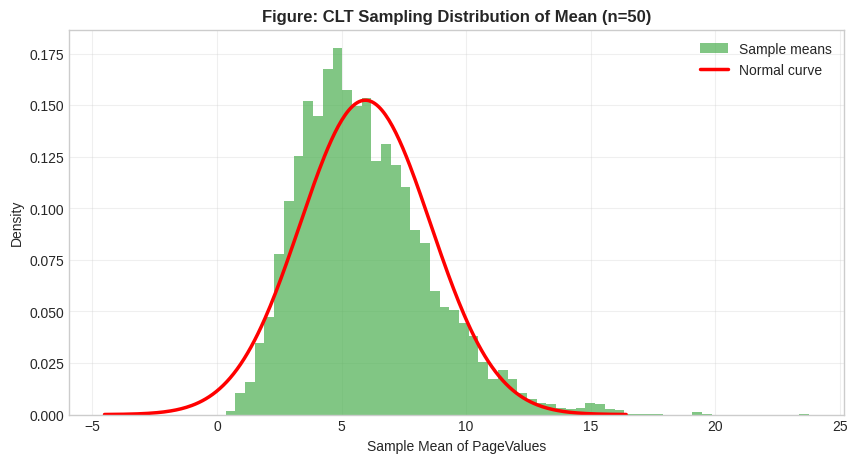

In [ ]:
plt.figure(figsize=(10,5))

# ── CLT: Sampling distribution ──
plt.hist(
    sample_means,
    bins=60,
    density=True,
    color='#4CAF50',
    alpha=0.7,
    label='Sample means'
)

# ── Normal curve overlay ──
mu = sample_means.mean()
sig = sample_means.std()

x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
plt.plot(x, stats.norm.pdf(x, mu, sig), 'r-', lw=2.5, label='Normal curve')

# ── Titles and labels ──
plt.title(
    "Figure: CLT Sampling Distribution of Mean (n=50)",
    fontweight='bold'
)

plt.xlabel("Sample Mean of PageValues")
plt.ylabel("Density")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#Confidence Intervals for PageValues (Z-method)

pv   = df['PageValues']
n    = len(pv)
xbar = pv.mean()
s    = pv.std(ddof=1)      # Sample std (ddof=1 uses n-1 denominator for unbiased estimate)
se   = s / np.sqrt(n)      # Standard Error

print("PageValues — Key Statistics:")
print(f"  n     = {n:,}")
print(f"  x̄     = {xbar:.4f}")
print(f"  s     = {s:.4f}  (sample standard deviation)")
print(f"  SE    = s/√n = {se:.6f}")
print()

# Compute confidence intervals using Z critical values
# Large sample (n=12,205) → Z approximation is valid by Central Limit Theorem
for conf, z_crit in [(0.90, 1.645), (0.95, 1.960), (0.99, 2.576)]:
    margin = z_crit * se
    lo = xbar - margin
    hi = xbar + margin
    print(f"{int(conf*100)}% CI: x̄ ± {z_crit:.3f} × SE")
    print(f"       = {xbar:.4f} ± {margin:.4f}")
    print(f"       = ({lo:.4f},  {hi:.4f})")
    print(f"       Width = {hi - lo:.4f}")
    print()

PageValues — Key Statistics:
  n     = 12,205
  x̄     = 5.9496
  s     = 18.6537  (sample standard deviation)
  SE    = s/√n = 0.168848

90% CI: x̄ ± 1.645 × SE
       = 5.9496 ± 0.2778
       = (5.6718,  6.2273)
       Width = 0.5555

95% CI: x̄ ± 1.960 × SE
       = 5.9496 ± 0.3309
       = (5.6186,  6.2805)
       Width = 0.6619

99% CI: x̄ ± 2.576 × SE
       = 5.9496 ± 0.4350
       = (5.5146,  6.3845)
       Width = 0.8699



In [ ]:
# Hypothesis Testing (One-Sample Z-tests)
# ─────────────────────────────────────────────────

alpha = 0.05   # Significance level

# ── TEST 1: One-sample Z-test (BounceRates vs 2% benchmark) ──
br_data = df['BounceRates']
mu0_br  = 0.02
n1      = len(br_data)
xbar1   = br_data.mean()
se1     = br_data.std(ddof=1) / np.sqrt(n1)
z1      = (xbar1 - mu0_br) / se1
p1      = 2 * (1 - stats.norm.cdf(abs(z1)))

print("TEST 1: One-sample Z-test — BounceRates vs μ₀ = 0.02")
print(f"  H₀: μ = {mu0_br}  |  H₁: μ ≠ {mu0_br}")
print(f"  Sample mean = {xbar1:.6f}")
print(f"  SE          = {se1:.6f}")
print(f"  Z-statistic = {z1:.4f}")
print(f"  p-value     = {p1:.8f}")
print(f"  Decision    : {'REJECT H₀' if p1 < alpha else 'FAIL TO REJECT H₀'} at α={alpha}")
print()

# ── TEST 2: One-sample Z-test (New Visitor PageValues vs overall mean) ──
mu0_pv  = df['PageValues'].mean()          # Overall mean as benchmark
nv_pv   = df[df['VisitorType'] == 'New_Visitor']['PageValues']
n2      = len(nv_pv)
xbar2   = nv_pv.mean()
se2     = nv_pv.std(ddof=1) / np.sqrt(n2)
z2      = (xbar2 - mu0_pv) / se2
p2      = 2 * (1 - stats.norm.cdf(abs(z2)))

print("TEST 2: One-sample Z-test — New Visitor PageValues vs overall mean")
print(f"  H₀: μ_NV = {mu0_pv:.4f} (overall mean)  |  H₁: μ_NV ≠ {mu0_pv:.4f}")
print(f"  Sample mean (New Visitors) = {xbar2:.4f}  (n={n2:,})")
print(f"  SE          = {se2:.6f}")
print(f"  Z-statistic = {z2:.4f}")
print(f"  p-value     = {p2:.8f}")
print(f"  Decision    : {'REJECT H₀' if p2 < alpha else 'FAIL TO REJECT H₀'} at α={alpha}")
print()

# ── TEST 3: One-sample Z-test (Purchasing sessions ExitRates vs overall mean) ──
mu0_er  = df['ExitRates'].mean()           # Overall mean as benchmark
er_buy  = df[df['Revenue'] == True]['ExitRates']
n3      = len(er_buy)
xbar3   = er_buy.mean()
se3     = er_buy.std(ddof=1) / np.sqrt(n3)
z3      = (xbar3 - mu0_er) / se3
p3      = 2 * (1 - stats.norm.cdf(abs(z3)))

print("TEST 3: One-sample Z-test — ExitRates (Purchasing Sessions) vs overall mean")
print(f"  H₀: μ_buy = {mu0_er:.4f} (overall mean)  |  H₁: μ_buy ≠ {mu0_er:.4f}")
print(f"  Sample mean (Purchases) = {xbar3:.4f}  (n={n3:,})")
print(f"  SE          = {se3:.6f}")
print(f"  Z-statistic = {z3:.4f}")
print(f"  p-value     = {p3:.2e}")
print(f"  Decision    : {'REJECT H₀' if p3 < alpha else 'FAIL TO REJECT H₀'} at α={alpha}")

TEST 1: One-sample Z-test — BounceRates vs μ₀ = 0.02
  H₀: μ = 0.02  |  H₁: μ ≠ 0.02
  Sample mean = 0.020370
  SE          = 0.000410
  Z-statistic = 0.9040
  p-value     = 0.36599151
  Decision    : FAIL TO REJECT H₀ at α=0.05

TEST 2: One-sample Z-test — New Visitor PageValues vs overall mean
  H₀: μ_NV = 5.9496 (overall mean)  |  H₁: μ_NV ≠ 5.9496
  Sample mean (New Visitors) = 10.7786  (n=1,693)
  SE          = 0.709599
  Z-statistic = 6.8052
  p-value     = 0.00000000
  Decision    : REJECT H₀ at α=0.05

TEST 3: One-sample Z-test — ExitRates (Purchasing Sessions) vs overall mean
  H₀: μ_buy = 0.0415 (overall mean)  |  H₁: μ_buy ≠ 0.0415
  Sample mean (Purchases) = 0.0196  (n=1,908)
  SE          = 0.000377
  Z-statistic = -58.1330
  p-value     = 0.00e+00
  Decision    : REJECT H₀ at α=0.05


In [ ]:
# ─────────────────────────────────────────────────
# Correlation Analysis (Pearson)
# ─────────────────────────────────────────────────

print("Pearson Correlation Matrix (Focal Variables):")
print(
    df[focus_vars]
    .corr(method='pearson')
    .round(4)
    .to_string()
)

print("Pearson Correlations with Revenue:")
print("-" * 50)
print(f"{'Variable':<22} {'Pearson r':>12} {'p-value':>12}")
print("-" * 50)

for var in focus_vars:
    r, p = stats.pearsonr(df[var], df['Revenue_int'])
    print(f"{var:<22} {r:>12.4f} {p:>12.2e}")

print()



Pearson Correlation Matrix (Focal Variables):
                BounceRates  ExitRates  PageValues  ProductRelated
BounceRates          1.0000     0.9021     -0.1158         -0.1929
ExitRates            0.9021     1.0000     -0.1736         -0.2861
PageValues          -0.1158    -0.1736      1.0000          0.0542
ProductRelated      -0.1929    -0.2861      0.0542          1.0000
Pearson Correlations with Revenue:
--------------------------------------------------
Variable                  Pearson r      p-value
--------------------------------------------------
BounceRates                 -0.1451     2.07e-58
ExitRates                   -0.2043    3.55e-115
PageValues                   0.4919     0.00e+00
ProductRelated               0.1560     2.21e-67



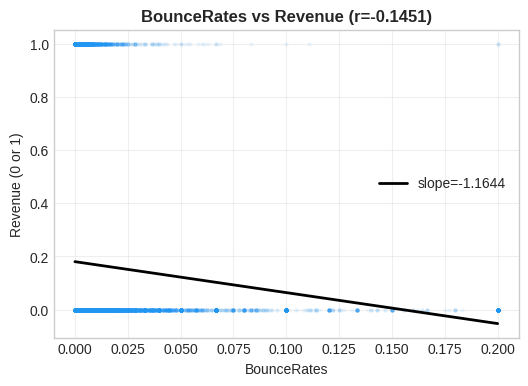

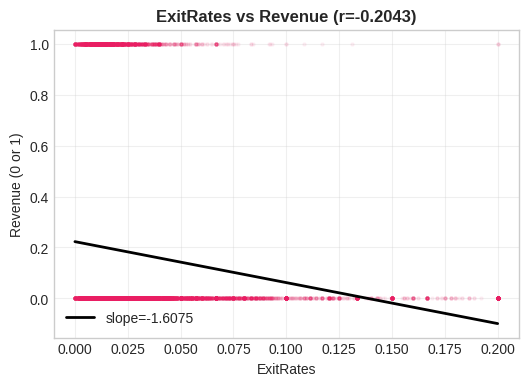

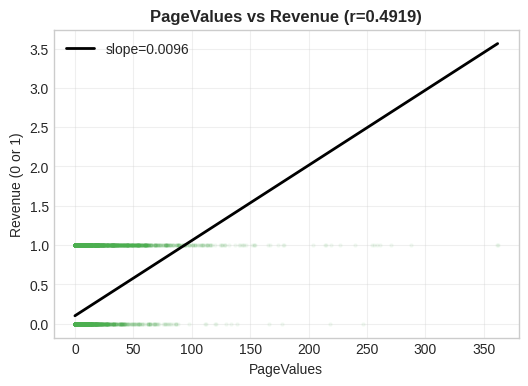

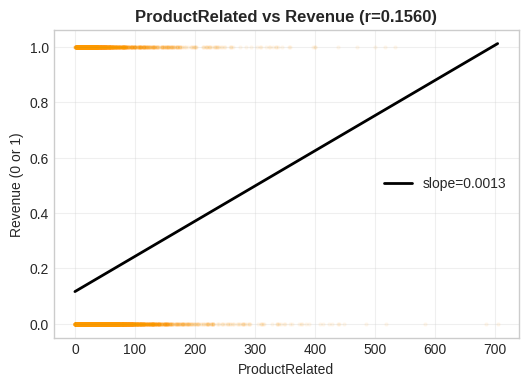

In [ ]:
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

for i, (var, col) in enumerate(zip(focus_vars, colors)):

    plt.figure(figsize=(6,4))

    # ── Scatter plot ──
    plt.scatter(df[var], df['Revenue_int'], alpha=0.05, color=col, s=5)

    # ── Regression line ──
    m, b = np.polyfit(df[var], df['Revenue_int'], 1)
    x_line = np.linspace(df[var].min(), df[var].max(), 200)
    plt.plot(x_line, m*x_line + b, 'k-', lw=2, label=f'slope={m:.4f}')

    # ── Correlation ──
    r, _ = stats.pearsonr(df[var], df['Revenue_int'])

    # ── Titles and labels ──
    plt.title(f'{var} vs Revenue (r={r:.4f})', fontweight='bold')
    plt.xlabel(var)
    plt.ylabel('Revenue (0 or 1)')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
# Linear Regression
# ─────────────────────────────────────────────────

y = df['Revenue_int']    # Dependent variable (binary: 0 or 1)

# ── Simple Linear Regression: PageValues only ──
X_simple = sm.add_constant(df['PageValues'])   # Adds intercept column of 1s
model_simple = sm.OLS(y, X_simple).fit()       # OLS = Ordinary Least Squares

print("=" * 65)
print("SIMPLE LINEAR REGRESSION: PageValues → Revenue")
print("=" * 65)
print(model_simple.summary())

# ── Multiple Linear Regression: all four predictors ──
X_multi = sm.add_constant(df[['BounceRates', 'ExitRates', 'PageValues', 'ProductRelated']])
model_multi = sm.OLS(y, X_multi).fit()

print()
print("=" * 65)
print("MULTIPLE LINEAR REGRESSION: All Four Predictors → Revenue")
print("=" * 65)
print(model_multi.summary())

# Extract and display key metrics
print()
print("Key Model Metrics:")
print(f"  R²          = {model_multi.rsquared:.4f}")
print(f"  Adjusted R² = {model_multi.rsquared_adj:.4f}")
print()
print("Estimated Equation:")
p = model_multi.params
print(f"  Revenue = {p['const']:.4f} + ({p['BounceRates']:.4f})×BounceRates")
print(f"           + ({p['ExitRates']:.4f})×ExitRates")
print(f"           + ({p['PageValues']:.6f})×PageValues")
print(f"           + ({p['ProductRelated']:.6f})×ProductRelated")



SIMPLE LINEAR REGRESSION: PageValues → Revenue
                            OLS Regression Results                            
Dep. Variable:            Revenue_int   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     3895.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:54:31   Log-Likelihood:                -3265.3
No. Observations:               12205   AIC:                             6535.
Df Residuals:                   12203   BIC:                             6549.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

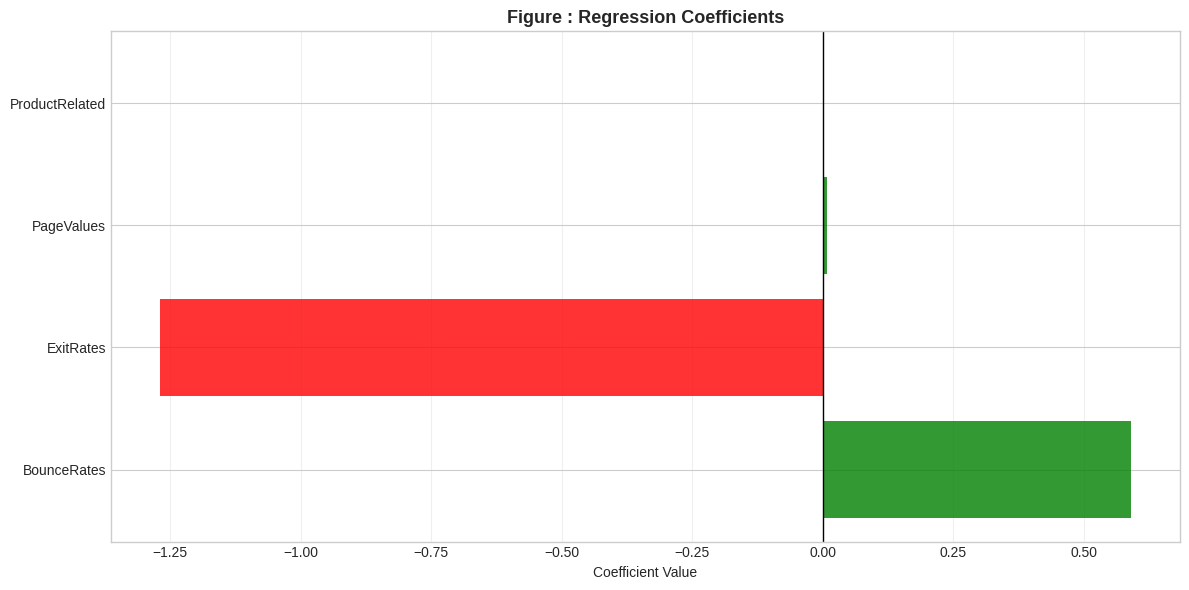

In [ ]:
# ── Figure : Coefficient bar chart ──
coef_df = model_multi.params[1:].reset_index()
coef_df.columns = ['Variable', 'Coefficient']
bar_colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=bar_colors, alpha=0.8)
ax.axvline(0, color='black', lw=1)
ax.set_title('Figure : Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()
